# 👩‍💻 Define Your Own ML Problem

## 📋 Overview
In this activity, you'll practice formulating machine learning problem statements using real-world datasets. The ability to define a precise ML problem is crucial for roles such as data scientists and machine learning engineers, as it helps align technical solutions with business objectives while considering constraints and success metrics.

## 🎯 Activity Goals
By completing this activity, you will:
- Develop the skill to transform business problems into ML problem statements
- Identify and articulate business and technical constraints
- Define clear success metrics aligned with business goals

## 🌎 Scenario
Imagine you are a data scientist at a company that aims to leverage data to improve its services. The leadership needs specific insights from data to make informed decisions. Your task is to define a clear ML problem using one of the provided datasets, considering the company's strategic goals.

## Step 1: Select a Dataset
A number of dataset csv files have been uploaded to this lab environment. Choose one dataset from the following options:
- Customer Churn (Telecom): `Telco-Customer-Churn.csv`
- Credit Card Fraud Detection: `creditcard.csv`
- Bike Sharing Demand Forecasting: `bikeshareday.csv`
- IMDb Sentiment Analysis (NLP): `IMDB_Dataset.csv`
- Customer Segmentation (Clustering): `marketing_campaign.csv`


In [1]:
# Load the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 10000)

In [2]:
df= pd.read_csv("creditcard.csv")
print(df.shape)
df.head(2)

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


💡 Tip: Select a dataset that aligns with your interests or professional field.

## Step 2: Examine the Data
Conduct a preliminary exploration of the dataset. Analyze the structure, key features, and possible target outputs.

**❗ Common Mistakes:**
- Overlooking data quality issues
- Ignoring potential target variables
- Failing to understand the dataset dimensions fully


In [3]:
# Explore the data
print(f"Shape of Data: {df.shape}")
print("\n----- Top 5 Rows of Data ------")
display(df.head())
print("\n----- Information of Data ------")
print(df.info())
print("\n----- Summmary of Data ------")
display(df.describe(percentiles=[i/100 for i in range(0, 101) if i%5==0]).T)
print("\n------- Number of Null Values ---------")
print(df.isnull().sum())

Shape of Data: (284807, 31)

----- Top 5 Rows of Data ------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



----- Information of Data ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,100%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,0.000000,25297.600000,35027.000000,41216.900000,47694.200000,54201.500000,60776.000000,67232.200000,73261.400000,78622.000000,84692.000000,108574.300000,120396.000000,126528.000000,132929.000000,139320.500000,145247.800000,151328.100000,157640.400000,164143.400000,172792.000000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-56.407510,-2.899147,-1.893272,-1.424545,-1.134663,-0.920373,-0.747294,-0.586700,-0.426756,-0.261842,0.018109,0.570896,1.035107,1.152127,1.224825,1.315642,1.694936,1.924286,2.015409,2.081223,2.454930,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-72.715728,-1.971975,-1.359862,-1.039394,-0.790814,-0.598550,-0.436393,-0.288185,-0.153805,-0.044536,0.065486,0.178647,0.302738,0.459688,0.636845,0.803724,0.957314,1.110220,1.326635,1.808585,22.057729,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-48.325589,-2.389740,-1.802587,-1.483557,-1.169050,-0.890365,-0.616806,-0.397156,-0.199061,0.000025,0.179846,0.331263,0.497040,0.664793,0.843541,1.027196,1.215700,1.417794,1.676173,2.062635,9.382558,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-5.683171,-2.195683,-1.656329,-1.356979,-1.066085,-0.848640,-0.696226,-0.560589,-0.394161,-0.196881,-0.019847,0.142120,0.284856,0.417078,0.558866,0.743341,0.986188,1.213360,1.482807,2.566501,16.875344,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-113.743307,-1.702021,-1.302171,-1.053683,-0.859581,-0.691597,-0.544455,-0.413004,-0.290112,-0.169525,-0.054336,0.064423,0.186625,0.318202,0.457029,0.611926,0.802235,1.042777,1.407893,2.098960,34.801666,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-26.160506,-1.406757,-1.167450,-1.015736,-0.878153,-0.768296,-0.667845,-0.572757,-0.479473,-0.374254,-0.274187,-0.168713,-0.048200,0.077642,0.223245,0.398565,0.628995,0.949038,1.509365,3.160382,73.301626,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-43.557242,-1.434423,-1.078148,-0.846610,-0.683316,-0.554076,-0.426020,-0.286806,-0.159341,-0.051778,0.040103,0.122825,0.213512,0.319154,0.446175,0.570436,0.698332,0.854903,1.039387,1.407632,120.589494,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-73.216718,-0.842147,-0.458945,-0.341845,-0.266300,-0.208630,-0.158158,-0.110961,-0.066057,-0.022503,0.022358,0.069873,0.120489,0.177424,0.243400,0.327346,0.435529,0.578494,0.769381,1.049984,20.007208,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-13.434066,-1.758426,-1.294047,-1.016505,-0.808875,-0.643098,-0.502165,-0.371384,-0.257730,-0.151438,-0.051429,0.054936,0.176169,0.311033,0.445942,0.597139,0.791583,1.020710,1.301671,1.780783,15.594995,15.594995



------- Number of Null Values ---------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


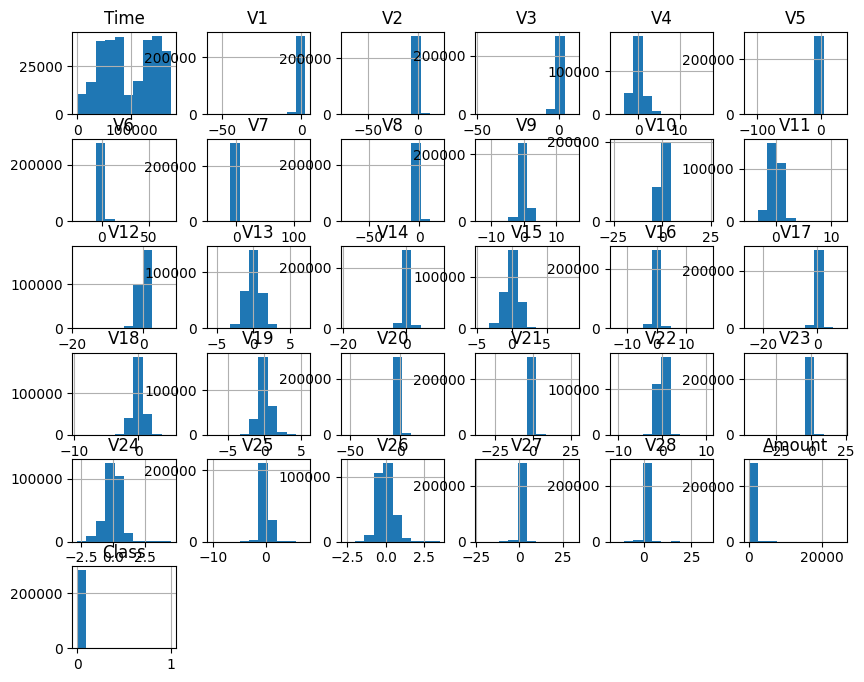

In [4]:
# Handle missing values (example: replacing missing values with the mode)
df.fillna(df.mode().iloc[0], inplace=True)

# Explore data types
print(df.dtypes)

# Visualize data distribution for numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_features].hist(figsize=(10, 8))
plt.show()

# Visualize data distribution for categorical features
categorical_features = df.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(df[feature])
    plt.title(f'Distribution of {feature}')
    plt.show()

## Step 3: Define the Business Problem
Identify a relevant business issue this dataset could help solve. Frame a clear business goal such as reducing churn rate or detecting fraud.

**Business Problem:** ...

**Ans :**

Credit card fraud is a significant concern for financial institutions and consumers alike. It's crucial for credit card companies to detect fraudulent transactions quickly and accurately to protect their customers.

The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

## Step 4: Translate to an ML Problem Statement
Articulate the ML problem by specifying predictions or classifications. Ensure it links back to business objectives with specificity, measurability, and feasibility.

**ML Problem Statement:** ...

Develop a binary classification model that predicts whether a given credit card transaction is fraudulent or legitimate based on transaction attributes (e.g., amount, time, location, anonymized features). The model should maximize precision and recall for the fraud class to minimize false positives and false negatives, thereby reducing financial losses and improving customer trust.


## Step 5: Identify Constraints and Success Metrics
Consider technical constraints like data availability and ethical considerations. Define what success looks like (e.g., precision, recall).

**Constraints:** ...

- **Class Imbalance**: Fraudulent transactions are extremely rare compared to legitimate ones, which can bias models toward predicting the majority class.
- **Data Privacy & Ethics**: Sensitive financial data must be handled with strict privacy protocols. Model decisions should be explainable to avoid unfair bias against certain users.
- **Real-Time Inference Requirements**: The model must be lightweight and fast enough for deployment in real-time transaction systems.
- **Limited Feature Interpretability**: Many datasets (like the popular Kaggle one) use anonymized features (V1–V28), making feature engineering and explainability more challenging.
- **False Positives Impact**: Flagging legitimate transactions as fraud can frustrate customers and damage trust, so precision must be carefully balanced.

**Success Metrics:** ...

| Metric              | Why It Matters                                                                 |
|---------------------|--------------------------------------------------------------------------------|
| **Recall (Fraud Class)** | Captures how many actual frauds are detected. High recall reduces financial loss. |
| **Precision (Fraud Class)** | Ensures flagged transactions are truly fraudulent. High precision avoids customer disruption. |
| **F1 Score**         | Balances precision and recall, especially useful in imbalanced datasets.       |
| **ROC-AUC**          | Measures overall model discrimination between fraud and non-fraud.             |
| **Latency**          | Time taken to make predictions—critical for real-time systems.                 |
| **Model Interpretability** | Stakeholders must understand why a transaction was flagged. SHAP values or decision trees help. |

## ✅ Success Checklist
- Is the problem statement specific and measurable?
- Are constraints and resources well-identified?
- Are success metrics properly aligned with business goals?
## 💡 Key Points
- Business problem articulation is crucial for ML problem framing
- Aligning with strategic goals optimizes ML project success
- Balancing constraints with objectives ensures feasible solutions
## 📚 Exemplar Solution
Here’s an example using the Customer Churn dataset:

- Business Problem: High churn leads to revenue loss.
- ML Problem Statement: "Create a predictive model to identify likely churners from the past six months’ data."
- Constraints: Limited computational power, privacy concerns.
- Success Metrics: Recall rate ≥ 0.85, Precision > 0.60.

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("Telco-Customer-Churn.csv")

# Display the first few rows of the dataset
print(data.head())

# Summary statistics
print(data.describe())

# Checking for missing values
print(data.isnull().sum())

# Handle missing values (example: replacing missing values with the mode)
data.fillna(data.mode().iloc[0], inplace=True)

# Explore data types
print(data.dtypes)

# Visualize data distribution for numerical features
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_features].hist(figsize=(10, 8))
plt.show()

# Visualize data distribution for categorical features
categorical_features = data.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data[feature])
    plt.title(f'Distribution of {feature}')
    plt.show()

    
```
</details>



### How does your work compare?
- Is your ML problem statement clear and directly linked to the business problem?
- Have you adequately addressed the constraints?
## 🚀 Next Steps
In the next module, you'll apply these problem statements to data collection and preprocessing, forming a solid basis for subsequent modeling phases.